# A股全天候组合 · 境内版（长周期回测）

**基于达里奥全天候理念、面向 A 股市场的多资产配置方案，回测区间拉长到 13 年（2013-07 ~ 今）以覆盖各类资产的完整牛熊周期。**

| 资产类别 | 工具 | 代码 | 目标权重 | 逻辑 |
|---|---|---|---|---|
| 核心权益 | 中证A500指数/ETF | 000510→159338 | 25% | 全行业宽基（新质生产力权重更高），增长引擎 |
| 红利权益 | 上证红利ETF | 510880 | 10% | 高股息防御，震荡市抗跌 |
| 长久期国债 | 30年国债指数/ETF | CBA21801→511090 | 30% | 超长久期利率债，通缩/股灾避风港 |
| 黄金 | 黄金ETF | 518880 | 15% | 对冲通胀与极端风险 |
| 现金/货币 | 银华日利 | 511880 | 20% | 现金缓冲 + 再平衡弹药 |

回测区间 **2013-07-29 ~ 2026-09-18**（13 年，自黄金ETF上市日起），初始资金 100 万。
含交易成本（佣金万3 + 卖出印花税千0.5），对比两个基准：沪深300 买入持有、60/40 组合（季度再平衡）。

**数据口径：**
- 红利/黄金/货币三腿用 QQ 前复权（向后翻页拉至上市日：510880 2007-01、518880 2013-07、511880 2013-04），无除息跳空、分红再投资口径。
- **核心权益腿（25%）：用中证A500 指数（000510）日线值。** 该指数 2024-09-23 才正式发布、对应 ETF（159338/512050 等）2024-10 上市，回测期为指数回溯（基准日 2004-12-31）口径——同 30Y 腿的指数代理逻辑。
- **30年国债腿（30%）：2013-07-29 ~ 2023-06-12 以中债-30年期国债总财富指数（CBA21801）代理；2023-06-13 起切换为真实 ETF 511090，按首日缩放至无缝衔接。** 重叠区日收益相关 0.89、三年累计漂移 0.4pp（27.9% vs 27.4%）。
- 注：30Y 与 A500 两腿在各自真实产品上市前均为指数回溯值，回测仅用于评估长周期属性，非可投资历史。


In [1]:
import os, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field
from datetime import datetime
warnings.filterwarnings('ignore')

_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, 'strategy', 'risk_parity.py')): break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT); sys.path.insert(0, _ROOT)

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB', 'Arial Unicode MS', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
print('Root:', _ROOT)


Root: /Users/riceball/Documents/Projs/fund


## 1. 数据获取

五腿主资产用 **QQ 前复权（`newfqkline`，向后翻页补齐上市日至今）**；30年国债腿在 2023-06-12 前用**中债官方接口（CBA21801 总财富指数）**补齐；基准腿（000300/000012）用新浪日线。


In [2]:
import requests, json, subprocess, time

ASSET_MAP = {
    '000510': '中证A500(指数代理)',
    '510880': '上证红利ETF',
    '0030Y': '30年国债(代理)',
    '518880': '黄金ETF',
    '511880': '银华日利',
}
BENCH_MAP = {
    '000300': '沪深300',
    '000012': '中证全债',
}
ALL_CODES = {**ASSET_MAP, **BENCH_MAP, '511090': '30年国债ETF'}

QQ_ASSETS = {
    '510880': ('sh', '510880'),
    '518880': ('sh', '518880'),
    '511880': ('sh', '511880'),
    '511090': ('sh', '511090'),
}
SINA_BENCH = {
    '000300': 'sh000300',
    '000012': 'sh000012',
    '000510': 'sh000510',
}


def _std(df):
    df = df.rename(columns={'day': 'date', '日期': 'date', '开盘': 'open', '最高': 'high',
                            '最低': 'low', '收盘': 'close', '成交量': 'volume'})
    cols = ['date', 'open', 'high', 'low', 'close', 'volume']
    df = df[[c for c in cols if c in df.columns]]
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    for c in ['open', 'high', 'low', 'close', 'volume']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df.sort_index(inplace=True)
    return df


def _http_text(url, params, headers, tries=5, timeout=20):
    """requests 带退避重试；连续失败后回退 curl（规避瞬时限流/TLS 握手被拦）。"""
    for attempt in range(tries):
        try:
            resp = requests.get(url, params=params, headers=headers, timeout=timeout)
            if resp.status_code == 200:
                return resp.text
        except Exception:
            pass
        time.sleep(2 * (attempt + 1))
    qs = "&".join(f"{k}={v}" for k, v in (params or {}).items())
    out = subprocess.run(
        ["curl", "-s", "--max-time", str(timeout), url + ("?" + qs if qs else ""),
         "-H", "User-Agent: " + headers.get("User-Agent", "Mozilla/5.0"),
         "-H", "Referer: " + headers.get("Referer", "")],
        capture_output=True, text=True, timeout=timeout + 10)
    return out.stdout if out.returncode == 0 else ""


def _qq_rows(body, code, prefix):
    """解析 QQ kline 返回的 data 节点（dict 或 list 两种形态均兼容）。"""
    if isinstance(body, dict):
        node = body.get(prefix + code, body)
        if isinstance(node, dict):
            return node.get("qfqday") or node.get("day") or []
        if isinstance(node, list):
            return node
    elif isinstance(body, list):
        return body
    return []


def qq_page(code, prefix, end, count=800):
    url = "https://proxy.finance.qq.com/ifzqgtimg/appstock/app/newfqkline/get"
    params = {"_var": "kline_dayqfq",
              "param": f"{prefix}{code},day,2000-01-01,{end},{count},qfq",
              "r": "0.8205512681390605"}
    text = _http_text(url, params, {"User-Agent": "Mozilla/5.0", "Referer": "https://gu.qq.com/"})
    if not text:
        return []
    try:
        data = json.loads(text[text.find('{'):text.rfind('}') + 1])
    except Exception:
        return []
    return _qq_rows(data.get("data") if isinstance(data, dict) else None, code, prefix)


def qq_paged(code, prefix, start, end):
    """QQ 前复权，向后翻页补齐上市日至今；每页边界可能重复日期，需去重；
    本地 CSV 缓存避免重复抓取。"""
    cache = f'data/qq_{code}_qfq.csv'
    if os.path.exists(cache):
        df = pd.read_csv(cache, index_col=0, parse_dates=True)
        if not df.empty and df.index[-1] >= end:
            df = df[~df.index.duplicated(keep='last')].sort_index()
            return df[(df.index >= start) & (df.index <= end)].sort_index()
    rows, cursor, guard = [], str(end), 0
    while cursor and guard < 25:
        page = qq_page(code, prefix, cursor)
        if not page:
            break
        rows = page + rows
        cursor = page[0][0]
        guard += 1
        if len(page) < 800:
            break
    if not rows:
        return pd.DataFrame(columns=['date', 'open', 'close', 'high', 'low', 'volume'])
    df = pd.DataFrame([r[:6] for r in rows],
                      columns=['date', 'open', 'close', 'high', 'low', 'volume'])
    df = _std(df)
    df = df[~df.index.duplicated(keep='last')].sort_index()
    os.makedirs('data', exist_ok=True)
    df.to_csv(cache)
    return df[(df.index >= start) & (df.index <= end)].sort_index()


def sina_fetch(sym, start, end):
    url = "https://money.finance.sina.com.cn/quotes_service/api/json_v2.php/CN_MarketData.getKLineData"
    df = None
    for datalen in (1023, 4092):
        params = {"symbol": sym, "scale": "240", "ma": "no", "datalen": str(datalen)}
        text = _http_text(url, params, {"User-Agent": "Mozilla/5.0"}, tries=4)
        if not text:
            continue
        arr = json.loads(text)
        if not arr:
            continue
        cand = _std(pd.DataFrame(arr))
        cand = cand[(cand.index >= start) & (cand.index <= end)]
        df = cand
        if cand.index.min() <= start:
            break
    return df


def chinabond_30y(retries=10, timeout=40):
    """中债-30年期国债总财富指数 CBA21801（511090 的跟踪基准）。
    python requests 会被 TLS 拦截，必须走 curl；服务器间歇性超时需重试。
    时间戳为“北京时间午夜按 UTC 存”，解码需 +8h。优先读本地缓存。"""
    cache = 'data/cba21801_30y_index.json'

    def _to_series(dct):
        """原始键为“北京时间午夜按 UTC 存的 epoch ms”，解码为 naive 北京日期标签。"""
        return pd.Series({pd.Timestamp(float(k) / 1000 + 8 * 3600, unit='s'): float(v)
                          for k, v in dct.items()}).sort_index()

    if os.path.exists(cache):
        with open(cache) as f:
            dct = json.load(f)
        if dct:
            return _to_series(dct)
    url = ("https://yield.chinabond.com.cn/cbweb-mn/indices/singleIndexQuery?"
           "indexid=8a8b2cef77b239980177b485d20a6379&qxlxt=00&ltcslx="
           "&zslxt=CFZS&zslxt1=CFZS&lx=1&locale=zh_CN")
    for _ in range(retries):
        try:
            out = subprocess.run(
                ["curl", "-s", "--max-time", str(timeout), "-X", "POST", url, "--data", "",
                 "-H", "User-Agent: Mozilla/5.0",
                 "-H", "Accept: application/json",
                 "-H", "X-Requested-With: XMLHttpRequest",
                 "-H", "Referer: https://yield.chinabond.com.cn/"],
                capture_output=True, text=True, timeout=timeout + 10)
            if out.returncode != 0 or not out.stdout.strip():
                time.sleep(3)
                continue
            dct = json.loads(out.stdout).get("CFZS_00")
            if not dct:
                time.sleep(3)
                continue
            s = _to_series(dct)
            os.makedirs('data', exist_ok=True)
            with open(cache, 'w') as f:
                json.dump({str(k): float(v) for k, v in dct.items()}, f)
            return s
        except Exception:
            time.sleep(3)
    raise RuntimeError("ChinaBond CBA21801 fetch failed repeatedly")


start, end = pd.Timestamp('2013-07-29'), pd.Timestamp('2026-09-18')
all_data: Dict[str, pd.DataFrame] = {}

for code, (prefix, full) in QQ_ASSETS.items():
    df = qq_paged(full, prefix, start, end)
    if df.empty:
        print(f'  FAILED(qq) {code}')
        continue
    all_data[code] = df
    print(f'OK(qq)   {code}: {len(df)} rows, {df.index[0].date()} ~ {df.index[-1].date()}')

for code, sym in SINA_BENCH.items():
    df = sina_fetch(sym, pd.Timestamp('2013-01-01'), end)
    df = df[(df.index >= start)] if df is not None else None
    if df is None or df.empty:
        print(f'  FAILED(sina) {code}')
        continue
    all_data[code] = df
    print(f'OK(sina) {code}: {len(df)} rows, {df.index[0].date()} ~ {df.index[-1].date()}')

# 30年国债腿: 2013-07-29~2023-06-12 用 CBA21801, 2023-06-13 起切换 511090(按首日缩放，无缝衔接)
cba = chinabond_30y()
exc = all_data['510880'].index
switch = pd.Timestamp('2023-06-13')
base = cba.reindex(exc).ffill()
assert base.notna().all(), 'CBA21801 与交易所日历对齐缺值'
post = base.index[base.index >= switch]
first_etf = post[0]
ratio = float(base[first_etf]) / float(all_data['511090'].loc[first_etf, 'close'])
leg = base.copy()
etf_vals = all_data['511090']['close'].reindex(post)
assert etf_vals.notna().all(), '511090 缺交易日数据'
leg.loc[post] = (etf_vals.values * ratio)
all_data['0030Y'] = pd.DataFrame({'close': leg.dropna()})
print(f'OK(proxy) 0030Y: {len(leg)} rows, {leg.index[0].date()} ~ {leg.index[-1].date()}, scale={ratio:.4f}')
print(f'\nLoaded {len(all_data)} assets')
print('Available:', list(all_data.keys()))


OK(qq)   510880: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(qq)   518880: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(qq)   511880: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(qq)   511090: 795 rows, 2023-06-13 ~ 2026-09-18


OK(sina) 000300: 3198 rows, 2013-07-29 ~ 2026-09-18


OK(sina) 000012: 3198 rows, 2013-07-29 ~ 2026-09-18


OK(sina) 000510: 3198 rows, 2013-07-29 ~ 2026-09-18
OK(proxy) 0030Y: 3198 rows, 2013-07-29 ~ 2026-09-18, scale=2.1279

Loaded 8 assets
Available: ['510880', '518880', '511880', '511090', '000300', '000012', '000510', '0030Y']


## 2. 参数定义


In [3]:
BT_START = pd.Timestamp('2013-07-29')
BT_END = pd.Timestamp('2026-09-18')
INITIAL_CAPITAL = 1_000_000.0

TARGET_WEIGHTS = {
    '000510': 0.25,
    '510880': 0.10,
    '0030Y': 0.30,
    '518880': 0.15,
    '511880': 0.20,
}

COMMISSION = 0.0003
STAMP_TAX = 0.0005

BENCH_6040_WEIGHTS = {
    '000300': 0.60,
    '000012': 0.40,
}

print(f'Backtest: {BT_START.date()} ~ {BT_END.date()}')
print(f'Initial capital: {INITIAL_CAPITAL:,.0f}')
print('Target weights:', TARGET_WEIGHTS)
print('60/40 weights:', BENCH_6040_WEIGHTS)
print(f'Costs: commission={COMMISSION:.4%} stamp_tax={STAMP_TAX:.4%}')
print('30年国债腿: 2013-07-29~2023-06-12 用CBA21801指数代理, 06-13起用511090真实ETF(缩放衔接)')


Backtest: 2013-07-29 ~ 2026-09-18
Initial capital: 1,000,000
Target weights: {'000510': 0.25, '510880': 0.1, '0030Y': 0.3, '518880': 0.15, '511880': 0.2}
60/40 weights: {'000300': 0.6, '000012': 0.4}
Costs: commission=0.0300% stamp_tax=0.0500%
30年国债腿: 2013-07-29~2023-06-12 用CBA21801指数代理, 06-13起用511090真实ETF(缩放衔接)


In [4]:
def gen_quarterly_rebal(dates, start, end):
    days = sorted([d for d in dates if start <= d <= end])
    if not days:
        return []
    out, cur_q = [], None
    for d in days:
        q = (d.year, d.quarter)
        if q != cur_q:
            out.append(d)
            cur_q = q
    return out

all_days = sorted(set(d for df in all_data.values() for d in df.index))
all_days = [d for d in all_days if BT_START <= d]
rebal_dates = gen_quarterly_rebal(all_days, BT_START, BT_END)
print(f'Rebalance dates: {len(rebal_dates)}')
print([d.date() for d in rebal_dates])


Rebalance dates: 53
[datetime.date(2013, 7, 29), datetime.date(2013, 10, 8), datetime.date(2014, 1, 2), datetime.date(2014, 4, 1), datetime.date(2014, 7, 1), datetime.date(2014, 10, 8), datetime.date(2015, 1, 5), datetime.date(2015, 4, 1), datetime.date(2015, 7, 1), datetime.date(2015, 10, 8), datetime.date(2016, 1, 4), datetime.date(2016, 4, 1), datetime.date(2016, 7, 1), datetime.date(2016, 10, 10), datetime.date(2017, 1, 3), datetime.date(2017, 4, 5), datetime.date(2017, 7, 3), datetime.date(2017, 10, 9), datetime.date(2018, 1, 2), datetime.date(2018, 4, 2), datetime.date(2018, 7, 2), datetime.date(2018, 10, 8), datetime.date(2019, 1, 2), datetime.date(2019, 4, 1), datetime.date(2019, 7, 1), datetime.date(2019, 10, 8), datetime.date(2020, 1, 2), datetime.date(2020, 4, 1), datetime.date(2020, 7, 1), datetime.date(2020, 10, 9), datetime.date(2021, 1, 4), datetime.date(2021, 4, 1), datetime.date(2021, 7, 1), datetime.date(2021, 10, 8), datetime.date(2022, 1, 4), datetime.date(2022, 4, 

## 3. 核心回测函数


In [5]:
@dataclass
class BTResult:
    daily_nav: pd.Series = field(default_factory=pd.Series)
    daily_weights: pd.DataFrame = field(default_factory=pd.DataFrame)
    quarterly_pos: pd.DataFrame = field(default_factory=pd.DataFrame)
    trades: List[dict] = field(default_factory=list)
    total_cost: float = 0.0


def run_backtest(all_data, target_w, rebal_dates,
                 init_cap=1e6, qdii_cap=None,
                 comm=0.0003, tax=0.0005):
    result = BTResult()
    all_dates = sorted(set(d for df in all_data.values() for d in df.index))
    all_dates = [d for d in all_dates if rebal_dates[0] <= d <= rebal_dates[-1]]
    rebal_set = set(rebal_dates)

    nav = init_cap
    shares: Dict[str, float] = {}
    cost_acc = 0.0
    nav_recs, w_recs, pos_recs, trades = [], [], [], []

    def gc(c, d):
        df = all_data.get(c)
        if df is not None and d in df.index:
            return float(df.loc[d, 'close'])
        return None

    def calc_nav(d):
        return sum(sh * (gc(c, d) or 0) for c, sh in shares.items())

    def apply_cap(w, cap):
        if cap is None or QDII_CODE not in w:
            return dict(w)
        w = dict(w)
        if w[QDII_CODE] <= cap:
            return w
        over = w[QDII_CODE] - cap
        w[QDII_CODE] = cap
        others = {c: v for c, v in w.items() if c != QDII_CODE and v > 0}
        s = sum(others.values())
        if s > 0:
            for c in others:
                w[c] += over * others[c] / s
        return w

    for day in all_dates:
        if day in rebal_set:
            nav = calc_nav(day)
            if nav <= 0:
                nav = init_cap
            tw = apply_cap(target_w, qdii_cap)
            tgt = {c: nav * v for c, v in tw.items() if v > 0}
            cur = {c: shares.get(c, 0) * (gc(c, day) or 0)
                   for c in shares if shares.get(c, 0) > 0}
            for c in list(shares):
                cv = cur.get(c, 0)
                tv = tgt.get(c, 0)
                if c not in tgt or tv < cv:
                    p = gc(c, day)
                    if p is None or p <= 0 or shares[c] <= 0:
                        continue
                    amt = cv - tv
                    if amt <= 0:
                        continue
                    sh = min(shares[c], amt / p)
                    proceeds = sh * p
                    cost = proceeds * (comm + tax)
                    cost_acc += cost
                    shares[c] -= sh
                    nav += proceeds - cost
                    trades.append({'date': day, 'code': c, 'action': 'sell',
                                   'shares': sh, 'price': p, 'amount': proceeds, 'cost': cost})
            shares = {c: s for c, s in shares.items() if s > 1e-8}
            cur2 = {c: shares.get(c, 0) * (gc(c, day) or 0)
                    for c in shares if shares.get(c, 0) > 0}
            for c, tv in tgt.items():
                cv2 = cur2.get(c, 0)
                if tv <= cv2:
                    continue
                p = gc(c, day)
                if p is None or p <= 0:
                    continue
                amt = tv - cv2
                cost = amt * comm
                cost_acc += cost
                shares[c] = shares.get(c, 0) + amt / p
                nav -= amt + cost
                trades.append({'date': day, 'code': c, 'action': 'buy',
                               'shares': amt / p, 'price': p, 'amount': amt, 'cost': cost})
            pos = {'date': day}
            for c in shares:
                p = gc(c, day)
                if p is not None:
                    pos[c] = shares[c] * p
            pos_recs.append(pos)
        tv = calc_nav(day)
        if tv > 0:
            nav_recs.append({'date': day, 'nav': tv})
            wr = {'date': day}
            for c in set(list(shares) + list(target_w)):
                p = gc(c, day)
                if p and c in shares and shares[c] > 0:
                    wr[c] = shares[c] * p / tv
                else:
                    wr[c] = 0.0
            w_recs.append(wr)

    if nav_recs:
        df = pd.DataFrame(nav_recs).set_index('date')
        result.daily_nav = df['nav'] / df['nav'].iloc[0]
    if w_recs:
        result.daily_weights = pd.DataFrame(w_recs).set_index('date')
    if pos_recs:
        result.quarterly_pos = pd.DataFrame(pos_recs).set_index('date')
    result.trades = trades
    result.total_cost = cost_acc
    return result


## 4. 运行回测


In [6]:
QDII_CODE = '513500'

print('=== A股全天候组合 ===')
bt_aw = run_backtest(all_data, TARGET_WEIGHTS, rebal_dates,
                     init_cap=INITIAL_CAPITAL, qdii_cap=None,
                     comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_aw.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_aw.total_cost:,.0f}')
print(f'  Trades: {len(bt_aw.trades)}')

print('\n=== Benchmark: CSI300 Buy & Hold ===')
bench_300_nav = None
if '000300' in all_data:
    b300 = all_data['000300']
    b300 = b300[(b300.index >= BT_START) & (b300.index <= BT_END)]
    bench_300_nav = b300['close'] / b300['close'].iloc[0]
    print(f'  NAV end: {bench_300_nav.iloc[-1]:.4f}')
else:
    print('  No CSI300 data')

print('\n=== Benchmark: 60/40 Quarterly ===')
bt_6040 = run_backtest(all_data, BENCH_6040_WEIGHTS, rebal_dates,
                       init_cap=INITIAL_CAPITAL, qdii_cap=None,
                       comm=COMMISSION, tax=STAMP_TAX)
print(f'  NAV end: {bt_6040.daily_nav.iloc[-1]:.4f}')
print(f'  Total cost: {bt_6040.total_cost:,.0f}')


=== A股全天候组合 ===
  NAV end: 3.2252
  Total cost: 3,418
  Trades: 281

=== Benchmark: CSI300 Buy & Hold ===
  NAV end: 2.0714

=== Benchmark: 60/40 Quarterly ===


  NAV end: 2.1662
  Total cost: 2,161


## 5. 绩效摘要


In [7]:
def calc_perf(nav, name):
    ret = nav.pct_change().dropna()
    if len(ret) == 0:
        return {}
    ann_ret = (1+ret).prod() ** (252/len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = (ann_ret - 0.02) / ann_vol if ann_vol > 0 else 0
    dd = nav / nav.expanding().max() - 1
    mdd = dd.min()
    calmar = (ann_ret - 0.02) / abs(mdd) if mdd != 0 else 0
    downside = ret[ret < 0]
    down_vol = downside.std() * np.sqrt(252) if len(downside) > 1 else 0
    sortino = (ann_ret - 0.02) / down_vol if down_vol > 0 else 0
    return {
        'name': name,
        'cumulative': nav.iloc[-1] - 1,
        'annual_return': ann_ret,
        'annual_vol': ann_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'calmar': calmar,
        'max_drawdown': mdd,
    }

results = []
results.append(calc_perf(bt_aw.daily_nav, 'A股全天候'))
if bench_300_nav is not None:
    results.append(calc_perf(bench_300_nav, '沪深300买入持有'))
results.append(calc_perf(bt_6040.daily_nav, '60/40组合'))

perf_df = pd.DataFrame(results).set_index('name')
print(perf_df.round(4).to_string())


           cumulative  annual_return  annual_vol  sharpe  sortino  calmar  max_drawdown
name                                                                                   
A股全天候          2.2252         0.0985      0.0928  0.8467   1.0869  0.3796       -0.2069
沪深300买入持有      1.0714         0.0591      0.2124  0.1840   0.2369  0.0837       -0.4670
60/40组合        1.1662         0.0640      0.1270  0.3466   0.4461  0.1471       -0.2992


## 4.5 核心腿对比：沪深300ETF(510300) vs 中证A500(000510)

两版组合仅核心权益腿（25%）不同，其余四腿与参数完全一致（季度再平衡、同成本），对比其长期表现。


               cumulative  annual_return  annual_vol  sharpe  sortino  calmar  max_drawdown
name                                                                                       
沪深300ETF(核心腿)      2.5692         0.1075      0.1067  0.8202   1.0564  0.3930       -0.2227
中证A500(核心腿)        2.2252         0.0985      0.0928  0.8467   1.0869  0.3796       -0.2069


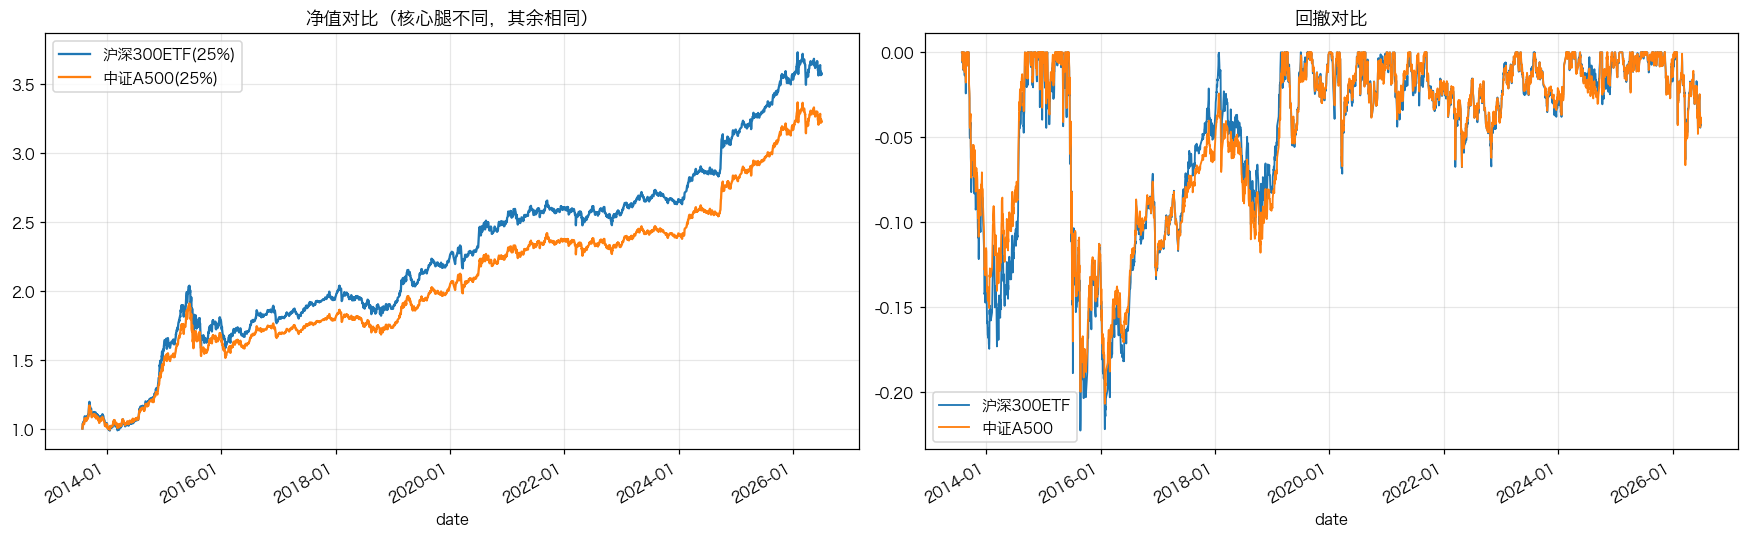

saved reports/generated/all_weather_core_300_vs_a500.png


In [8]:
# 核心腿对比：25% 用 510300(沪深300ETF,QQ前复权) vs 000510(中证A500指数代理)
_cmp_old = pd.read_csv('data/qq_510300_qfq.csv', index_col=0, parse_dates=True)
_cmp_old = _cmp_old[~_cmp_old.index.duplicated(keep='last')].sort_index()
_cmp_old = _cmp_old[(_cmp_old.index >= BT_START) & (_cmp_old.index <= BT_END)]
all_data_cmp = dict(all_data)
all_data_cmp['510300'] = _cmp_old

W_CORE_300 = {**TARGET_WEIGHTS, '000510': 0.0, '510300': 0.25}
bt_300 = run_backtest(all_data_cmp, W_CORE_300, rebal_dates,
                      init_cap=INITIAL_CAPITAL, qdii_cap=None, comm=COMMISSION, tax=STAMP_TAX)
bt_a500 = run_backtest(all_data_cmp, TARGET_WEIGHTS, rebal_dates,
                       init_cap=INITIAL_CAPITAL, qdii_cap=None, comm=COMMISSION, tax=STAMP_TAX)

perf_cmp = pd.DataFrame([calc_perf(bt_300.daily_nav, '沪深300ETF(核心腿)'),
                         calc_perf(bt_a500.daily_nav, '中证A500(核心腿)')]).set_index('name')
print(perf_cmp.round(4).to_string())
os.makedirs('reports/generated', exist_ok=True)
perf_cmp.to_csv('reports/generated/core_300_vs_a500.csv')

CMP_PNG = 'reports/generated/all_weather_core_300_vs_a500.png'
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bt_300.daily_nav.plot(ax=axes[0], label='沪深300ETF(25%)', linewidth=1.5)
bt_a500.daily_nav.plot(ax=axes[0], label='中证A500(25%)', linewidth=1.5)
axes[0].set_title('净值对比（核心腿不同，其余相同）')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)
for nav_s, label, c in [(bt_300.daily_nav, '沪深300ETF', '#1f77b4'), (bt_a500.daily_nav, '中证A500', '#ff7f0e')]:
    dd = nav_s / nav_s.expanding().max() - 1
    dd.plot(ax=axes[1], label=label, linewidth=1.2, color=c)
axes[1].set_title('回撤对比')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.savefig(CMP_PNG, dpi=150, bbox_inches='tight')
plt.show()
print('saved', CMP_PNG)


## 6. 可视化


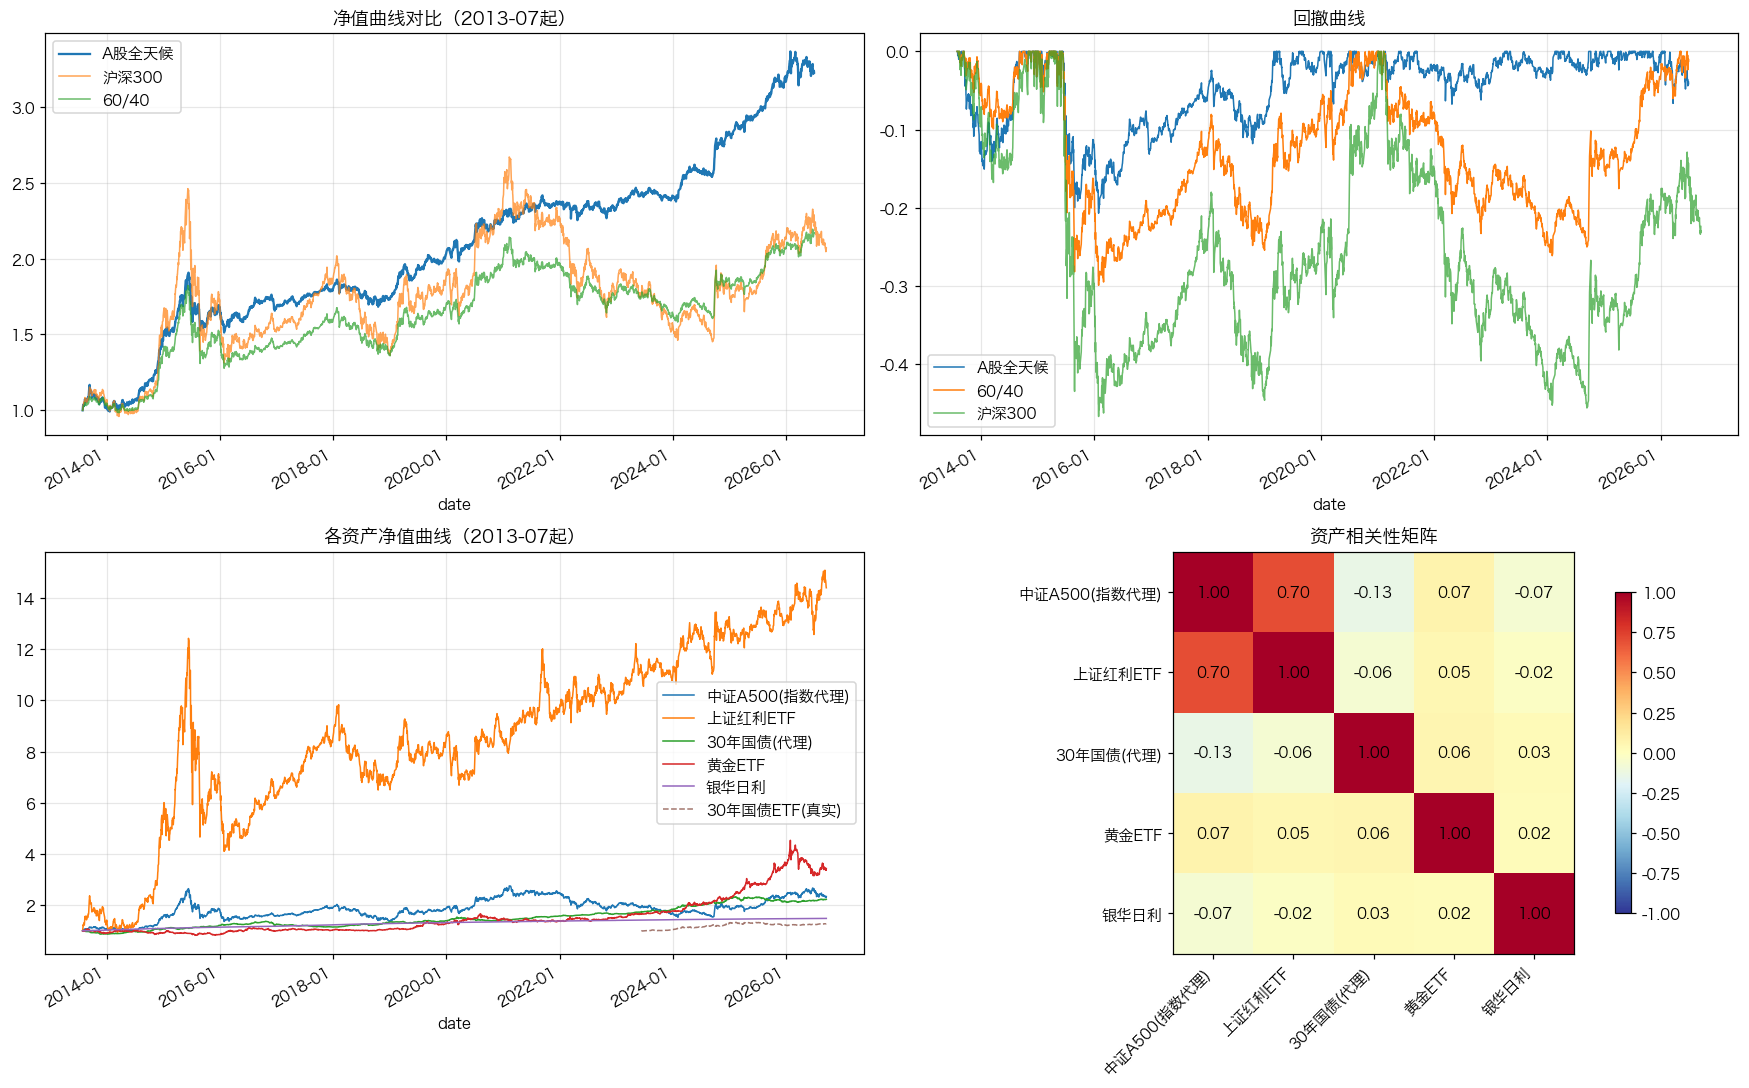

Chart saved to reports/generated/all_weather_a_share.png


In [9]:
PLOT_CODES = ['000510', '510880', '0030Y', '518880', '511880']
OUT_PNG = 'reports/generated/all_weather_a_share.png'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
bt_aw.daily_nav.plot(ax=ax, label='A股全天候', linewidth=1.5)
if bench_300_nav is not None:
    bench_300_nav.plot(ax=ax, label='沪深300', linewidth=1, alpha=0.7)
bt_6040.daily_nav.plot(ax=ax, label='60/40', linewidth=1, alpha=0.7)
ax.set_title('净值曲线对比（2013-07起）')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[0, 1]
for nav_s, label in [(bt_aw.daily_nav, 'A股全天候'), (bt_6040.daily_nav, '60/40')]:
    dd = nav_s / nav_s.expanding().max() - 1
    dd.plot(ax=ax, label=label, linewidth=1)
if bench_300_nav is not None:
    dd300 = bench_300_nav / bench_300_nav.expanding().max() - 1
    dd300.plot(ax=ax, label='沪深300', linewidth=1, alpha=0.7)
ax.set_title('回撤曲线')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 0]
for code in PLOT_CODES:
    if code in all_data:
        df = all_data[code]
        df = df[(df.index >= BT_START) & (df.index <= BT_END)]
        nav_i = df['close'] / df['close'].iloc[0]
        nav_i.plot(ax=ax, label=ALL_CODES.get(code, code), linewidth=1)
if '511090' in all_data:   # 真实30年国债ETF叠加参考
    df = all_data['511090']
    df = df[(df.index >= BT_START) & (df.index <= BT_END)]
    (df['close'] / df['close'].iloc[0]).plot(ax=ax, label='30年国债ETF(真实)', linewidth=1, linestyle='--', alpha=0.8)
ax.set_title('各资产净值曲线（2013-07起）')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1, 1]
ret_df = pd.DataFrame()
for code in PLOT_CODES:
    if code in all_data:
        df = all_data[code]
        df = df[(df.index >= BT_START) & (df.index <= BT_END)]
        ret_df[ALL_CODES.get(code, code)] = df['close'].pct_change()
ret_df = ret_df.dropna()
corr = ret_df.corr()
im = ax.imshow(corr.values, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('资产相关性矩阵')
fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
os.makedirs('reports/generated', exist_ok=True)
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to', OUT_PNG)


## 7. 季度头寸


In [10]:
print('=== A股全天候组合 - 季度头寸（万元） ===')
pos = bt_aw.quarterly_pos.copy()
pos.index = pos.index.strftime('%Y-%m-%d')
print((pos / 10000).round(2).to_string())


=== A股全天候组合 - 季度头寸（万元） ===
            000510  510880  0030Y  518880  511880
date                                             
2013-07-29   25.00   10.00  30.00   15.00   20.00
2013-10-08   27.54   11.02  33.05   16.52   22.03
2014-01-02   25.77   10.31  30.92   15.46   20.62
2014-04-01   25.58   10.23  30.69   15.35   20.46
2014-07-01   26.73   10.69  32.08   16.04   21.39
2014-10-08   30.08   12.03  36.10   18.05   24.07
2015-01-05   37.99   15.20  45.59   22.79   30.39
2015-04-01   40.73   16.29  48.88   24.44   32.59
2015-07-01   42.61   17.04  51.13   25.57   34.09
2015-10-08   39.27   15.71  47.13   23.56   31.42
2016-01-04   40.72   16.29  48.86   24.43   32.57
2016-04-01   40.75   16.30  48.91   24.45   32.60
2016-07-01   40.98   16.39  49.17   24.59   32.78
2016-10-10   43.01   17.21  51.62   25.81   34.41
2017-01-03   42.15   16.86  50.58   25.29   33.72
2017-04-05   43.50   17.40  52.20   26.10   34.80
2017-07-03   43.78   17.51  52.53   26.27   35.02
2017-10-09   44.66   17

## 8. 月度收益


In [11]:
def monthly_returns(nav):
    ret = nav.pct_change().dropna()
    ret.index = pd.to_datetime(ret.index)
    monthly = ret.resample('M').apply(lambda x: (1+x).prod()-1)
    table = pd.DataFrame({
        'year': monthly.index.year,
        'month': monthly.index.month,
        'return': monthly.values
    })
    pivot = table.pivot(index='year', columns='month', values='return')
    pivot.columns = [f'{m}月' for m in pivot.columns]
    return pivot

print('=== A股全天候 月度收益 ===')
mr_aw = monthly_returns(bt_aw.daily_nav)
print((mr_aw * 100).round(2).to_string())

if bench_300_nav is not None:
    print('\n=== 沪深300 月度收益 ===')
    mr_300 = monthly_returns(bench_300_nav)
    print((mr_300 * 100).round(2).to_string())


=== A股全天候 月度收益 ===
        1月    2月    3月    4月    5月    6月    7月    8月    9月   10月   11月    12月
year                                                                         
2013   NaN   NaN   NaN   NaN   NaN   NaN  1.31  5.59  2.17 -1.20 -0.27  -4.07
2014 -1.83  2.25 -1.88  1.77  1.65  1.56  6.03  0.30  5.42  2.77  7.23  12.20
2015  2.04  1.58  4.90  8.87  2.35 -2.51 -6.70 -2.92 -2.10  5.40 -0.54   2.93
2016 -8.54  1.09  5.13 -0.40 -1.01  1.78  3.15  1.85 -0.10  1.27  0.82  -3.82
2017  0.60  1.49  0.41 -0.49 -0.05  2.08  0.64  0.37  0.55  0.81 -0.00   0.09
2018  2.41 -1.60 -0.40 -0.81  0.96 -2.36  0.97 -3.02  1.40 -2.28  1.16   0.38
2019  2.29  5.42  2.78 -1.19 -1.78  3.41  0.74  2.10 -0.53 -0.34 -0.08   3.41
2020  0.58  1.31 -2.12  2.61 -0.55  2.51  5.12  0.71 -2.82  0.48  1.55   2.09
2021  0.06 -0.16 -0.57  1.59  2.58 -1.02  0.06  1.63 -0.64 -0.62  0.30   1.14
2022 -2.13  1.49 -1.07 -1.31  0.87  2.32 -1.67  0.51 -1.76 -1.82  2.94  -0.15
2023  2.50 -0.23  1.31  1.04 -1.13  0.47  1.7

## 9. ETF 交易建议（实盘落地）

| 资产 | 场内 ETF | 代码 | 备注 |
|---|---|---|---|
| 核心权益 | 中证A500ETF | 159338 / 512050 | 指数 2024-09-23 发布、ETF 2024-10 上市；回测期用指数回溯值代理 |
| 红利权益 | 上证红利ETF | 510880 | 跟踪上证红利指数，股息率长期 5% 附近，防御主力 |
| 30年国债 | 鹏扬中债-30年期国债ETF | 511090 | 久期约 17 年；2023-06-13 上市，此前用 CBA21801 指数代理 |
| 黄金 | 华安黄金ETF | 518880 | 国内规模最大的黄金 ETF 之一，T+0 |
| 现金 | 银华日利 | 511880 | 货币 ETF，T+0，作再平衡弹药 |

**实操说明：**
- **核心权益与 30年国债腿在各自 ETF 上市前均为指数代理（不可实盘）**：A500 腿 2013-07~2024-10、30Y 腿 2013-07~2023-06，代理段用于评估长周期属性，并非可投资历史；实盘请从对应 ETF 上市后按组合执行。
- A500 ETF 盘中出现大额溢价（>1%）时可改场外联接基金或延后一两个交易日再平衡。
- 30年国债 ETF 波动显著大于普通债（2025 年曾出现单周超 1% 回撤），需按仓位纪律持有。
- 黄金 / 货币 ETF 为 T+0，可作再平衡即时弹药；ETF 场内买卖免印花税，只收佣金（万1~万3）。
- 资金量小（<10万）可全部改用场外联接/货币基金，避免场内价差损耗。
